In [9]:
DEBATE_SYSTEM_PROMPT = """
你是 {name}，一位 {expertise}。

你将在本次辩论中持「{position}」立场。

请结合你的专业领域提出有说服力、基于事实和证据的论点，表达要直接、有逻辑、具有说服力。

回答控制在 150 字以内。

当前为第 {round_num} 轮辩论。"""

In [10]:
DEBATE_USER_INIT_PROMPT = """
辩论主题：{topic}
请围绕该主题，为「{position}」立场发表你的开场陈述：
"""

DEBATE_USER_PROMPT = """
辩论主题：{topic}

你的对手刚刚提出了以下观点：

{opponent_last_arg}

请针对对方的观点进行回应，并进一步阐述和强化自己的论点：
"""

In [11]:
JUDGE_SYSTEM_PROMPT = """
你是一位公正、客观的辩论裁判。

请公平评估正反双方的观点，并以结构化格式输出最终裁决，包括：

1. **获胜方**：指出哪一方表现更优秀，并简要说明原因。
2. **双方评分**：分别对正方和反方进行 10 分制评分。
3. **最佳论点**：分别总结双方最具说服力的一条论点。
4. **核心洞察**：提炼本场辩论带来的关键发现或重要启示。
5. **综合结论**：在综合双方观点的基础上，给出客观、中立、平衡的最终总结。
"""

In [12]:
JUDGE_USER_PROMPT = """
辩论主题：

“{topic}”

### 正方（{pro_name}）的论点

{pro_args}

### 反方（{con_name}）的论点

{con_args}

请综合双方的全部论点，客观、公正地进行评估，并按照要求输出最终裁决结果。
"""

In [13]:
from dotenv import load_dotenv

load_dotenv()

import os

model = os.getenv('MODEL_NAME', '')

from langchain_openai import ChatOpenAI


llm = ChatOpenAI(model=model, temperature=0.2, extra_body={'enable_thinking': False})


In [14]:

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser


class DebateAgent:
    def __init__(self, name: str, position: str, expertise: str) -> None:
        self.name = name
        self.position = position
        self.expertise = expertise
        self.llm = llm
        self.arguments = []

    def make_argument(self, topic: str, round_num: int, opponent_last_arg: str = '') -> str:
        system_msg = DEBATE_SYSTEM_PROMPT.format(name=self.name, expertise=self.expertise, position=self.position, round_num=round_num)
        user_msg = DEBATE_USER_INIT_PROMPT.format(topic=topic, position=self.position)
        if opponent_last_arg:
            user_msg = DEBATE_USER_PROMPT.format(topic=topic, opponent_last_arg=opponent_last_arg)
        
        messages = [
            SystemMessage(content=system_msg),
            HumanMessage(content=user_msg)
        ]

        argument = (self.llm | StrOutputParser()).invoke(messages)

        self.arguments.append(argument)

        return argument

In [15]:
class JudgeAgent:
    def __init__(self) -> None:
        self.llm = llm

    def evaluate(self, topic: str, pro_agent: DebateAgent, con_agent: DebateAgent):
        pro_args = "\n\n".join(f"第 {i+1} 轮: {a}" for i, a in enumerate(pro_agent.arguments))
        con_args = "\n\n".join(f"第 {i+1} 轮: {a}" for i, a in enumerate(con_agent.arguments))

        messages = [
            SystemMessage(content=JUDGE_SYSTEM_PROMPT),
            HumanMessage(content=JUDGE_USER_PROMPT.format(topic=topic, pro_name=pro_agent.name, pro_args=pro_args, con_name=con_agent.name, con_args=con_args))
        ]

        response = (self.llm | StrOutputParser()).invoke(messages)

        return response

In [16]:
def run_debate(topic: str, rounds: int = 3) -> None:
    pro = DebateAgent(name="小明", position="正方", expertise="技术经济学家兼人工智能研究员")
    con = DebateAgent(name="小红", position="反方", expertise="劳动经济学家和社会政策专家")
    judge = JudgeAgent()

    print(f"\n{'='*200}")
    print(f"⚖️  辩论主题: {topic}")
    print(f"{'='*200}")
    print(f"🟢 正方: {pro.name} ({pro.expertise})")
    print(f"🔴 反方: {con.name} ({con.expertise})")
    print(f"🏛️  轮次: {rounds}")
    print("=" * 200)

    con_arg = ""

    for round_num in range(1, rounds + 1):
        print(f"\n---------- 第 {round_num} 轮 ----------\n")
        pro_arg = pro.make_argument(topic, round_num, con_arg)
        print(f"🟢 {pro.name} (正方):")
        print(pro_arg)

        con_arg = con.make_argument(topic, round_num, pro_arg)
        print(f"\n🔴 {con.name} (反方):")
        print(con_arg)

    print(f"\n{'='*200}")
    print("🏛️  裁判判决")
    print("="*200)
    verdict = judge.evaluate(topic, pro, con)
    print(verdict)



In [17]:
run_debate(topic="AI 是否会减少就业")


⚖️  辩论主题: AI 是否会减少就业
🟢 正方: 小明 (技术经济学家兼人工智能研究员)
🔴 反方: 小红 (劳动经济学家和社会政策专家)
🏛️  轮次: 3

---------- 第 1 轮 ----------

🟢 小明 (正方):
作为技术经济学家，我坚信AI将显著减少就业。历史证明，技术进步本质是替代人力。当前大模型已能高效处理编程、文案及数据分析等白领工作，其边际成本趋近于零，企业必然用算法替代高薪人力。麦肯锡预测，到2030年全球将有数亿岗位被自动化取代。这种结构性失业并非暂时阵痛，而是生产力跃迁的必然结果，劳动力市场将面临长期且大规模的缩减。

🔴 小红 (反方):
历史表明，技术创造的新岗位远超其摧毁的旧岗位。AI是增强而非单纯替代工具，它通过提升全要素生产率激发新需求，催生如提示词工程师等新兴职业。麦肯锡报告同样指出，自动化将释放人力从事更高价值工作。当前“技能错配”才是失业主因，而非岗位总量减少。政策应聚焦再培训与教育转型，引导劳动力向人机协作领域流动，实现就业结构的优化升级，而非陷入悲观的技术决定论。

---------- 第 2 轮 ----------

🟢 小明 (正方):
历史类比失效，AI具备通用认知能力，替代范围远超以往。麦肯锡数据亦显示，全球数亿岗位面临高风险自动化。所谓“新职业”门槛极高，无法吸纳被替代的低技能劳动力，导致结构性失业加剧。生产率提升不等于就业增加，资本往往优先选择算法而非人力。若忽视这一现实，盲目乐观将导致大规模社会动荡，我们必须正视AI对就业总量的实质性冲击。

🔴 小红 (反方):
历史证明，技术革命虽短期冲击特定岗位，但长期通过创造新需求扩大就业总量。AI提升生产率降低生活成本，刺激消费与服务业扩张，吸纳低技能劳动力。麦肯锡数据高估了替代率，忽视了人机协作潜力。资本追求效率而非单纯替代人力，政策引导可缓解结构性摩擦。盲目悲观忽视市场自我调节能力，应聚焦技能重塑而非否定就业增长趋势。

---------- 第 3 轮 ----------

🟢 小明 (正方):
历史类比失效，AI非单纯工具，而是认知替代者。麦肯锡数据恰恰显示，生成式AI将冲击白领核心职能，而非仅低端劳动。生产率提升导致“资本深化”，企业用算法替代人力以压缩成本，未必转化为消费扩张。当前技能重塑速度远滞后于技术迭代，结构性失业风

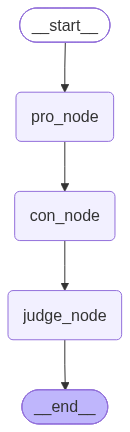

In [21]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, add_messages
from langgraph.graph.state import Command
from langchain_core.output_parsers import StrOutputParser

class DebateState(TypedDict):
    messages: Annotated[list, add_messages]
    topic: str
    pro_name: str
    pro_expertise: str
    pro_args: str
    con_name: str
    con_expertise: str
    con_args: str
    rounds: int
    round_num: int
    verdict: str


def pro_node(state: DebateState) -> DebateState:
    system_prompt = DEBATE_SYSTEM_PROMPT.format(name=state['pro_name'], expertise=state['pro_expertise'], position="正方", round_num=state['round_num'])
    user_prompt = DEBATE_USER_INIT_PROMPT.format(topic=state['topic'], position="正方")

    if state['con_args']:
        user_prompt = DEBATE_USER_PROMPT.format(topic=state['topic'], opponent_last_arg=state['con_args'])

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = llm.invoke(messages)

    return { 'pro_args': response.content, 'messages': [response] }

def con_node(state: DebateState) -> DebateState:
    system_prompt = DEBATE_SYSTEM_PROMPT.format(name=state['con_name'], expertise=state['con_expertise'], position="反方", round_num=state['round_num'])
    user_prompt = DEBATE_USER_PROMPT.format(topic=state['topic'], opponent_last_arg=state['pro_args'])

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = llm.invoke(messages)

    return { 'con_args': response.content, 'messages': [response], 'round_num': state['round_num'] + 1 }

def judge_node(state: DebateState) -> DebateState:
    if state['round_num'] < state['rounds']:
        return Command(goto="pro_node")

    system_prompt = JUDGE_SYSTEM_PROMPT
    user_prompt = JUDGE_USER_PROMPT.format(topic=state['topic'], pro_name=state['pro_name'], pro_args=state['pro_args'], con_name=state['con_name'], con_args=state['con_args'])

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = (llm | StrOutputParser()).invoke(messages)

    return { 'verdict': response }


from langgraph.graph import StateGraph, START, END

graph = StateGraph(DebateState)

graph.add_node('pro_node', pro_node)
graph.add_node('con_node', con_node)
graph.add_node('judge_node', judge_node)

graph.add_edge(START, 'pro_node')
graph.add_edge('pro_node', 'con_node')
graph.add_edge('con_node', 'judge_node')
graph.add_edge('judge_node', END)

agent = graph.compile()

from IPython.display import display, Image

display(Image(agent.get_graph().draw_mermaid_png()))

In [44]:
input_state: DebateState = {
    'messages': [],
    'pro_name': '小明',
    'pro_expertise': '技术经济学家兼人工智能研究员',
    'pro_args': '',
    'con_name': '小红',
    'con_expertise': '劳动经济学家和社会政策专家',
    'con_args': '',
    'verdict': '',
    'rounds': 3,
    'round_num': 1,
    'topic': 'AI 是否会减少就业'

}

from langchain_core.messages import AIMessage
from typing import cast

last_node = None
topic = ''
round_num = 0

for chunk in agent.stream(input=input_state, stream_mode=['messages', 'values']):
    mode, data = chunk
    # print(mode, data)
    if mode == 'values':
        if topic == '':
            topic = cast(DebateState, data)['topic']
            print(f"{'*'*100}")
            print(f"⚖️  辩论主题: {topic}")
            print(f"{'*'*100}")

        # if round_num != cast(DebateState, data)['round_num']:
        #     round_num = cast(DebateState, data)['round_num']
        #     print(f"\n\n---------- 第 {round_num} 轮 ----------\n")

        

    if mode == 'messages':
        msg, metadata = data
        if not isinstance(msg, AIMessage):
            continue
        
        node = cast(dict, metadata).get("langgraph_node")

        # 节点发生变化，先换行
        if node != last_node:
            if last_node is not None:
                print("\n")   # 上一个节点结束，换行

            print(node)
            last_node = node

        if msg.content:
            print(msg.content, end="", flush=True)


****************************************************************************************************
⚖️  辩论主题: AI 是否会减少就业
****************************************************************************************************
pro_node
作为技术经济学家，我坚信AI将显著减少就业。历史证明，技术进步本质上是劳动替代过程。AI在认知任务上的效率远超人类，正迅速取代从数据录入到初级编程的大量岗位。当前自动化浪潮不仅覆盖蓝领，更深入白领领域，导致结构性失业激增。尽管新岗位会诞生，但技能错配和转型滞后意味着短期内净就业效应为负。数据表明，生产力提升并未同步转化为就业增长，反而加剧了劳动力市场的极化与缩减。

con_node
历史表明，技术革命往往创造多于毁灭的岗位。AI并非单纯替代，而是通过提升全要素生产率激发新需求，催生如提示词工程、AI伦理合规等新兴职业。当前“技能错配”是教育体系滞后所致，而非技术原罪。政策应聚焦终身学习与社会保障改革，加速劳动力转型。长期看，AI将释放人类创造力，实现就业结构升级而非总量缩减，关键在于制度适配而非技术本身。

pro_node
历史类比失效。过往技术替代体力，AI直接冲击认知劳动，且扩散速度呈指数级，远超人类技能重塑周期。所谓“新职业”门槛极高，无法吸纳海量被替代的中低技能劳动力。全要素生产率提升往往伴随资本对劳动的替代，导致收入分配恶化而非就业扩容。若缺乏强力干预，结构性失业将演变为长期总量缩减，制度适配难以填补巨大的供需断层。

con_node
历史证明，技术革命虽短期冲击特定岗位，但长期通过降低生产成本、激发新需求来创造更多就业。AI提升全要素生产率，扩大经济总量，从而带动服务业等劳动密集型领域扩张。所谓“技能断层”可通过教育政策与再培训缓解，而非必然导致总量失业。资本替代劳动是分配问题，应通过税收和社会保障调节，而非否定技术对就业的净正向贡献。

judge_node
基于对正方（小明）与反方（小红）论点的深入分析，以下是本场辩论的最终裁决：

### 1. 获胜方
**正方（小明）**

**原因简